In [1]:
# -*- coding: utf-8 -*-
"""
2D static small-strain flat-punch problem using isoparametric FE
     _______↓↓↓↓________    
   /|___|___|___|___|___|/
   /|___|___|___|___|___|/
   /|___|___|___|___|___|/
   /|___|___|___|___|___|/
   /|___|___|___|___|___|/
   /|___|___|___|___|___|/
    ////////////////////
        
@author: Konstantinos Karapiperis
"""
import sys
import torch
import numpy as np
sys.path.insert(1,'src')
from readmesh import Mesh
from quadrature import Quadrature
from quad_element import QuadElement
from constitutive_model import ConstitutiveModel
from material_point import MaterialPoint
from assembler import Assembler
from solver import NewtoRaphsonSolver
from postprocessor import PostProcessor

=============================================================================<br>
Mesh data<br>
=============================================================================<br>

In [2]:
mesh = Mesh('input/nodal-coords.dat',
            'input/material-point-connectivity.dat',
            'input/essential-bcs.dat')
                 
n_nod, coord =  mesh.get_coords()
n_mat_pts, conn = mesh.get_conn()
ebcs = mesh.get_ebcs()
dim = 2   # number of spatial dimensions
n_dof = 2 # number of degrees of freedom
n_gp = 4  # number of gauss points/element

=============================================================================<br>
Constitutive <br>
=============================================================================<br>

In [3]:
# We have already trained a neural constitutive model (train_constitutive_model.py), here we load it    
model_name = 'src/neural-constitutive-model/model.pt'
eps_dim = 3 # as in training
hidden_dim = 32 # as in training
out_dim = 1 # as in training
layers = 4 # as in training
activation = torch.nn.Tanh() # as in training
constitutive_model = ConstitutiveModel(model_name, eps_dim=eps_dim,
                                       hidden_dim=hidden_dim,
                                       out_dim=out_dim, layers=layers,
                                       activation=activation, device='cpu')

=============================================================================<br>
Construct quadrature rule and isoparametric base element<br>
=============================================================================<br>

In [4]:
quadrature = Quadrature(dim,n_gp)
quad_element = QuadElement(dim,n_gp)

=============================================================================<br>
Construct elements (material points)<br>
=============================================================================<br>

In [5]:
mat_points = np.empty(n_mat_pts, dtype=object) 
rho = 0  # density (Kg/m^3)
t = 1    # thickness
for mp_idx in range(n_mat_pts):
    qp_index = mp_idx % n_gp
    mat_points[mp_idx] = MaterialPoint(mp_idx, rho, t, coord, conn[mp_idx], 
        quad_element, quadrature, qp_index, constitutive_model)

=============================================================================<br>
Assembler<br>
=============================================================================<br>

In [6]:
assembler = Assembler(mat_points, n_nod)

=============================================================================<br>
Solver<br>
=============================================================================<br>

In [7]:
num_steps = 10
max_iterations = 10
abs_tol = 1e-6
solver = NewtoRaphsonSolver(assembler, max_iterations)
displacements = np.zeros(n_nod * n_dof)

=============================================================================<br>
Force-displacement output<br>
=============================================================================<br>

In [8]:
forced_nodes = np.array(ebcs.dofs)[np.where(np.abs(ebcs.final_vals) > 0)]
top_force = np.zeros(num_steps+1)
top_disp = np.zeros(num_steps+1)

=============================================================================<br>
Solve the problem<br>
=============================================================================<br>

In [9]:
for step in range(num_steps):
    print('\nLoadstep', step)
    ebcs.scale(float(step+1)/num_steps)
    displacements = solver.compute_solution(ebcs, displacements, verbose=0, abs_tol=abs_tol)
    top_disp[step] = np.mean(displacements[forced_nodes])
    forces = assembler.assemble_force_vector()
    top_force[step] = np.sum(forces[forced_nodes])


Loadstep 0
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.42e-02
Residual:
 0.0

Loadstep 1
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.48e-02
Residual:
 0.0

Loadstep 2
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.51e-02
Residual:
 0.0

Loadstep 3
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.50e-02
Residual:
 0.0

Loadstep 4
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.50e-02
Residual:
 0.0

Loadstep 5
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.49e-02
Residual:
 0.0

Loadstep 6
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.48e-02
Residual:
 0.0

Loadstep 7
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.47e-02
Residual:
 0.0

Loadstep 8
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.46e-02
Residual:
 0.0

Loadstep 9
Iteration 0, Residual: 1.000000e+00
Increment norm: 3.44e-02
Residual:
 0.0


=============================================================================<br>
Save force-displacement data<br>
=============================================================================<br>

In [10]:
np.savetxt("output/force-displacement.dat", np.c_[top_disp,top_force],fmt='%.3f')

=============================================================================<br>
Plot deformed mesh<br>
=============================================================================<br>

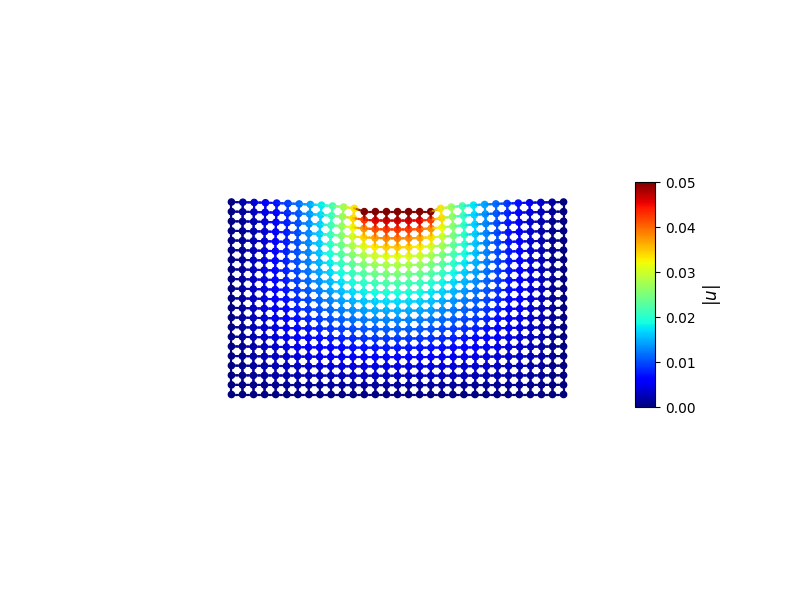

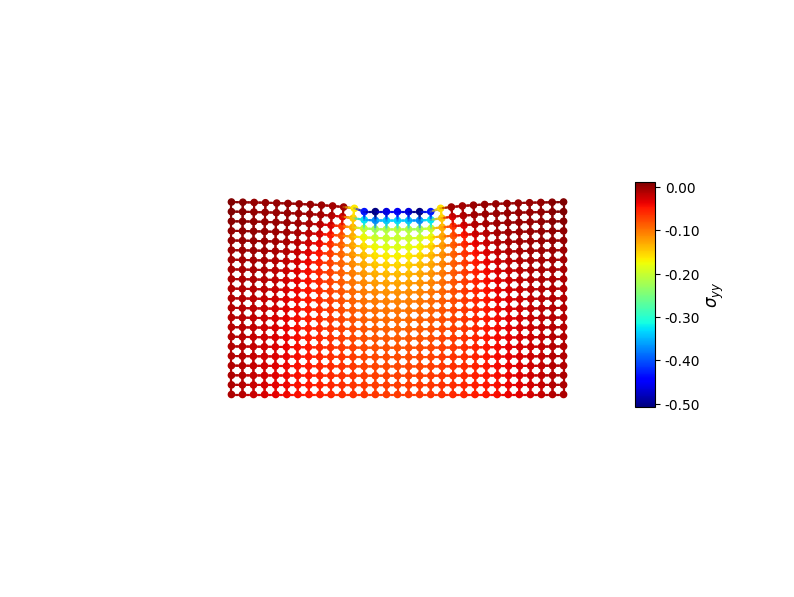

In [11]:
mag_factor = 1.
postprocessor = PostProcessor(coord, conn, mag_factor)
disp_norm = np.linalg.norm(displacements.reshape(-1,n_dof),axis=1)
postprocessor.plot_deformed_field(displacements, disp_norm, r'$|u|$')
sigma_yy = assembler.compute_node_stresses()[:,1,1]
postprocessor.plot_deformed_field(displacements, sigma_yy, r'$\sigma_{yy}$')